# Imports & Helper

In [1]:
# The following are my 'standard copy-paste' imports
# a bit overkill for the example here.
import os, sys, yaml, h5py, pickle, warnings

# Set number of threads
os.environ['KMP_DUPLICATE_LIB_OK']='True' # uncomment this line if omp error occurs on OSX for python 3
os.environ['OMP_NUM_THREADS']='4' # set number of OpenMP threads to run in parallel
os.environ['MKL_NUM_THREADS']='4' # set number of MKL threads to run in parallel

# Math
import numpy as np
np.set_printoptions(precision=3) ## print precision
## random numbers
from numpy.random import default_rng 

#import cmasher # more colormaps

# misc
from tqdm.notebook import tqdm, trange ## timing

In [2]:
%matplotlib inline 
#ipy magic for plotting in ipynb; other options are available

import matplotlib as mpl
from matplotlib import rcParams # global parameters of plot
from matplotlib import cm, colors # colormaps and colors for matplotlib
import matplotlib.pyplot as plt # matplotlib

# define directory where to save figures
fig_dir = "/Users/psch/Work/Figures/plotting_intro/everyday"
os.makedirs(fig_dir, exist_ok=True)

## Misc plotting def

In [3]:
# Misc global definitions
equivec      = np.linspace(0,1,11)[1:]
golden_ratio = (np.sqrt(5)+1)/2

# Some Definitions

SMALL_SIZE   = '20'
MEDIUM_SIZE  = '22'
LARGE_SIZE   = "24"
MAJOR_WIDTH  = 2
MAJOR_LENGTH = 8
MINOR_WIDTH  = 1.9
MINOR_LENGTH = 4
LINE_WIDTH   = 1.5

inch      = 1
a4_width  = 8.3*inch
a3_height = 11.7*inch

# add latex to your path
os.environ['PATH'] +=  os.pathsep + '/Library/TeX/texbin/'
# you may have to change the path to YOUR latex location
# this is the standard one for 


# use standard latex and not matplotlibs mathtex
rcParams['text.usetex'] = 'True'

# add packages
#print(rcParams.keys)
rcParams["text.latex.preamble"]=r"\usepackage{mathtools}" \
    + r"\usepackage{amssymb}" \
    + r"\usepackage{physics}" \
    + r"\usepackage{dsfont}"
    



rcParams_update = {
    "xtick.major.size"  : MAJOR_LENGTH,
    "ytick.major.size"  : MAJOR_LENGTH,
    "xtick.major.width" : MAJOR_WIDTH,
    "ytick.major.width" : MAJOR_WIDTH,
    "xtick.minor.size"  : MINOR_LENGTH,
    "ytick.minor.size"  : MINOR_LENGTH,
    "xtick.minor.width" : MINOR_WIDTH,
    "ytick.minor.width" : MINOR_WIDTH,
    "xtick.direction"   : "in",
    "ytick.direction"   : "in",
    'lines.linewidth'   : LINE_WIDTH,
    'font.size'         : MEDIUM_SIZE, # controls default text sizes
    'font.family'       : 'Times', # standard font for RevTex
    'font.serif'        : 'Mathtime Pro', # standard font for RevTex
    'axes.titlesize'    : MEDIUM_SIZE, # fontsize of the axes title
    'axes.labelsize'    : MEDIUM_SIZE, # fontsize of the x and y labels
    'axes.linewidth'    : MAJOR_WIDTH,
    'xtick.labelsize'   : MEDIUM_SIZE, # fontsize of the tick labels
    'ytick.labelsize'   : MEDIUM_SIZE, # fontsize of the tick labels
    'figure.titlesize'  : MEDIUM_SIZE, 
    'legend.fontsize'   : MEDIUM_SIZE, # legend fontsize
}

rcParams.update(rcParams_update)

# Plotting Example

We use the extraction of 1/e decay rates for functions $f(t;p)$ with parameter $p$ as a mock example 
to demonstrate a couple of useful everyday functionality.

In [9]:
# Make mock data
seed = 13*17
rng  = default_rng(seed)
noise = 0.01


times_vec = np.logspace(1,6, 1_000_001)# large data set for demonstation
params_vec = np.linspace(0,3,31)
decay_rate = 1e-4 * 10**(-params_vec)
# Make noisy
decay_rate *= (1+.1*rng.normal(size=decay_rate.shape))

data_arr = np.exp(- decay_rate[:,None]*times_vec[None,:])
## make noisy
data_arr *= (1+noise*rng.normal(size=data_arr.shape))

# Compute 1/e heating rates
Gamma_vec = np.zeros_like(params_vec)
extrapolated = np.zeros(params_vec.size, dtype=bool)

for n, _ in enumerate(params_vec):
    
    yvec = data_arr[n].copy()
    
    if yvec.min()<1/np.e:
        Gamma_vec[n] = 1/times_vec[np.abs(yvec-1/np.e).argmin()]
    else:
        Gamma_vec[n] = 1/ (times_vec[-1] / np.log(1/yvec[-1]) )
        extrapolated[n]=True
        
not_extrapolated = np.logical_not(extrapolated)
#print(Gamma_vec[extrapolated])

## Lazy plotting

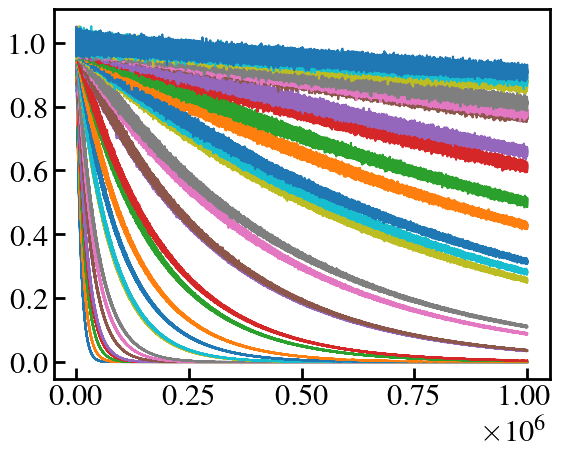

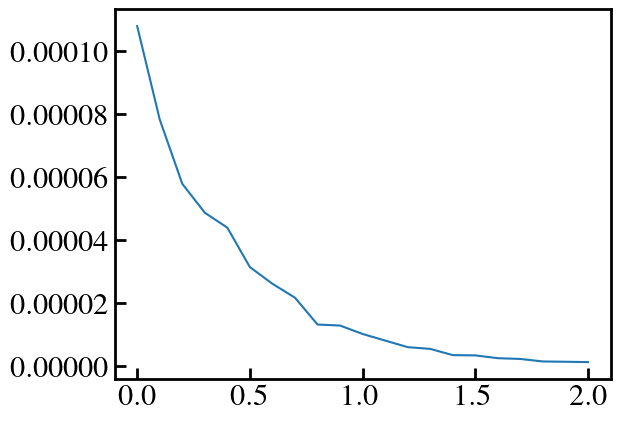

In [10]:
for n, p in enumerate(params_vec):
    plt.plot(
        times_vec,
        data_arr[n],
    )
plt.show()
plt.plot(params_vec[not_extrapolated], Gamma_vec[not_extrapolated])
plt.show()

## Basic plotting

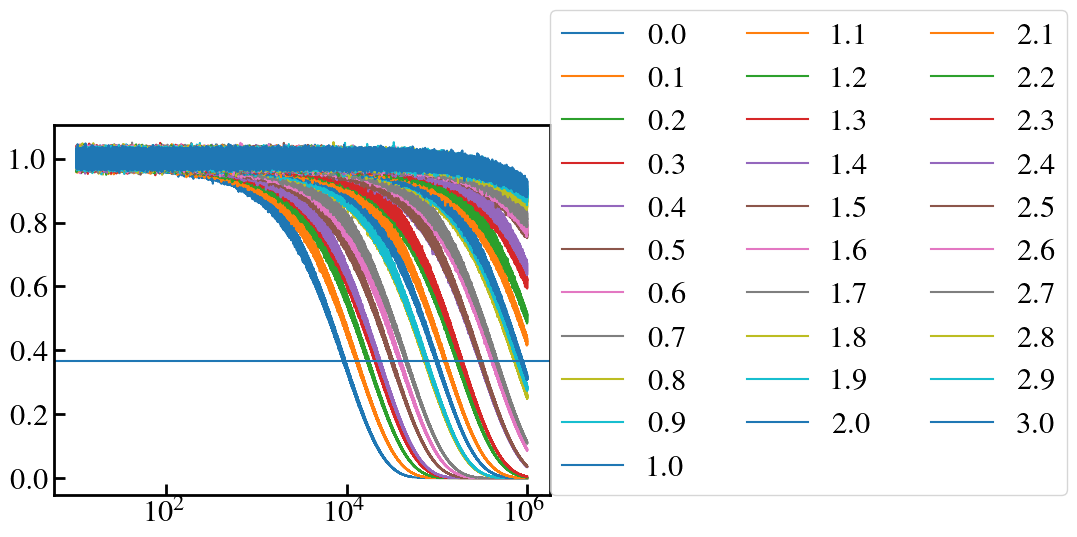

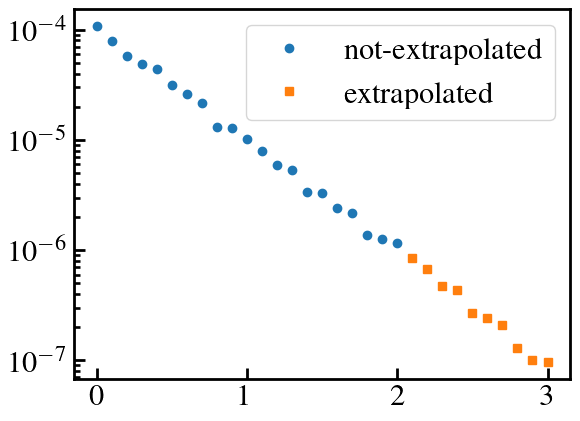

In [20]:
fig, ax = plt.subplots()
for n, p in enumerate(params_vec):
    ax.plot(
        times_vec,
        data_arr[n],
        label=f"{p:.1f}" # show only one digit after comma
    )
ax.legend(
    loc=(1,0),
    ncols=3,
)
ax.set_xscale("log")

ax.axhline(1/np.e)

# save figure
savefig=True
savefig=False
if savefig:
    plt.savefig(
        os.path.join(fig_dir, "basic.png"),
        dpi=150, # use smaller dpi bc figure will be super big anyway
        bbox_inches="tight" #makes sure nothing is cut of
    )
plt.show()

fig, ax = plt.subplots()

ax.plot(
    params_vec[not_extrapolated], 
    Gamma_vec[not_extrapolated], 
    "o",
    label=r"not-extrapolated"
)
ax.plot(
    params_vec[extrapolated], 
    Gamma_vec[extrapolated], 
    "s",
    label="extrapolated"
)
ax.set_yscale("log")
ax.legend()

plt.show()

one get's the idea but there are too many colors to distinguish the curves and the curves are quite noisy, plus pretty big legend, etc.

## Helpfull plotting

In [15]:
# Display different parameters as colorbar
## choose colorbar
cmap = cm.plasma_r
## normalization
norm = colors.Normalize(vmin=params_vec.min(), vmax=params_vec.max())
## scalar mappable to show cmap in plot
sm   = cm.ScalarMappable(cmap=cmap,norm=norm)


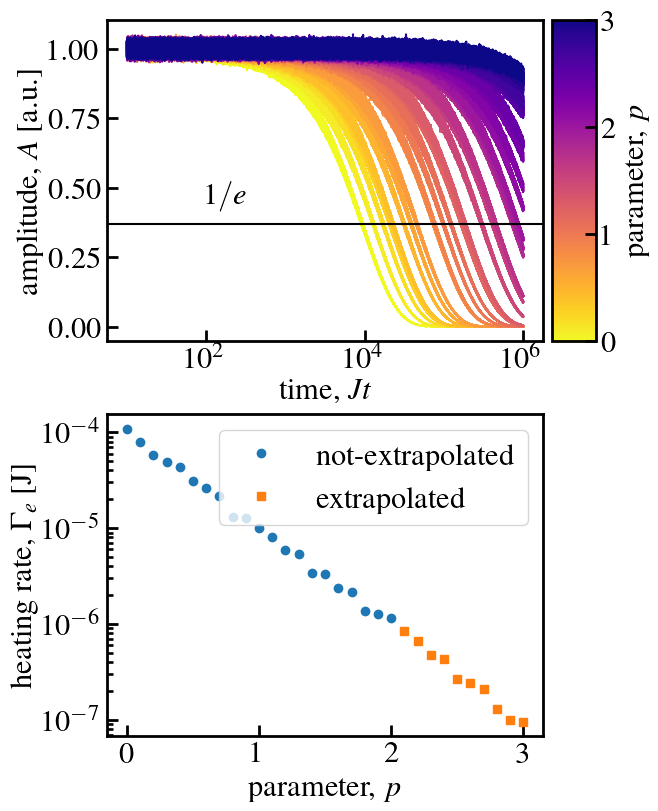

In [18]:
height=4
fig, ((ax_t, cax),(ax_gamma, empty)) = plt.subplots(
    figsize=(height*golden_ratio,2*height),
    ncols=2, nrows=2,
    width_ratios=(1,0.1),
    constrained_layout=True,# I only use this for non-publication figures
)
# Turn of second axis in lower row
empty.axis("off")

# Make Colorbar
fig.colorbar(sm,cax=cax)
cax.set_ylabel(r"parameter, $p$")


# Plot time data
for n, p in enumerate(params_vec):
    ax_t.plot(
        times_vec,
        data_arr[n],
        rasterized=True,
        color=cmap(norm(p))
    )

ax_t.set_xscale("log")

ax_t.axhline(
    1/np.e,
    c="k",
)
ax_t.text(
    100, 1.2/np.e, r"$1/e$"
)
ax_t.set_xlabel(r"time, $Jt$")
ax_t.set_ylabel(r"amplitude, $A$ [a.u.]")

# Plot decay rates
ax_gamma.plot(
    params_vec[not_extrapolated], 
    Gamma_vec[not_extrapolated], 
    "o",
    label=r"not-extrapolated"
)
ax_gamma.plot(
    params_vec[extrapolated], 
    Gamma_vec[extrapolated], 
    "s",
    label="extrapolated"
)
ax_gamma.set_yscale("log")
ax_gamma.legend()

ax_gamma.set_xlabel(r"parameter, $p$")
ax_gamma.set_ylabel(r"heating rate, $\Gamma_e$ [J]")


# save figure
savefig=True
savefig=False
if savefig:
    plt.savefig(
        os.path.join(fig_dir, "custom.pdf"),
        dpi=300, # use smaller dpi bc figure will be super big anyway
        bbox_inches="tight" #makes sure nothing is cut of
    )
    
plt.show()